<a href="https://colab.research.google.com/github/diegoVasquez600/Statistics_for_Analytics/blob/main/ANOVA_est_IUPB_Diego_Rios_Vasquez_Juan_David_Perez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

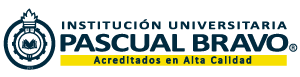

# **ANOVA**

## Entregable 5: ANOVA
## Estadistica para Analitica
## Profesora: Ingry Natalia Gómez Miranda
## Estudiantes:
  #### - Diego Alejanro Rios Vasquez
  #### - Juan David Perez

# **1. Presentación de los datos**

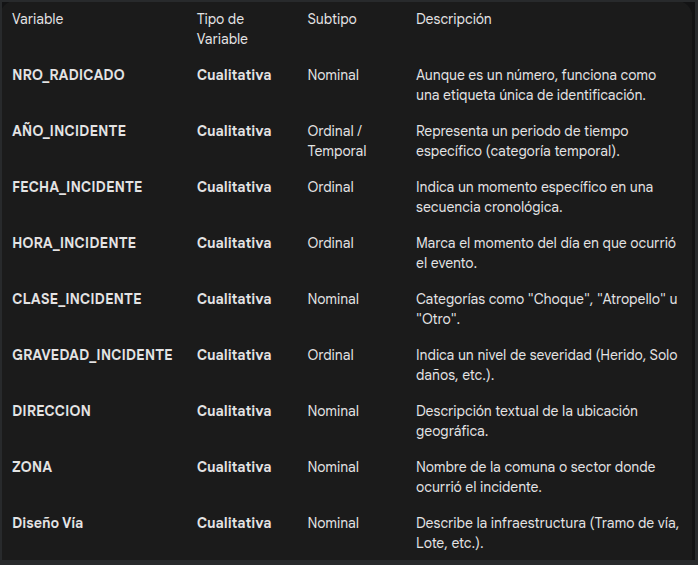

# **2. Cargar el conjunto de datos**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Cargando archivo desde el directorio de trabajo
from google.colab import files
import pandas as pd

# Cargar un archivo desde tu dispositivo local
Archivo = files.upload()

# Obtener la ruta del archivo cargado
Ruta = list(Archivo.keys())[0]

# Leer el archivo con pandas
datos = pd.read_csv(Ruta,sep=',')

# Mostrar los 10 primeros registros del DataFrame
print()
datos.head(10)

Saving incidentes_viales_motos.csv to incidentes_viales_motos (1).csv



,NRO_RADICADO,AÑO_INCIDENTE,FECHA_INCIDENTE,HORA_INCIDENTE,CLASE_INCIDENTE,GRAVEDAD_INCIDENTE,DIRECCION,ZONA,Diseño Vía
0,1471551,2015,10/01/2015,23:23:00,Choque,HERIDO,Carrera 80 Con Calle 44 B,COMUNA 12,Tramo de via
1,1471559,2015,10/01/2015,20:00:00,Atropello,HERIDO,Carrera 111 Con Calle 34 CC,COMUNA 13,Tramo de via
2,1471643,2015,10/01/2015,17:40:00,Choque,SOLO DA\xD1OS,Carrera 49 Con Calle 79,COMUNA 4,Tramo de via\r
3,1471663,2015,10/01/2015,20:20:00,Choque,SOLO DA\xD1OS,Calle 30 Con Carrera 79 A,COMUNA 16,Tramo de via\r
4,1471664,2015,10/01/2015,14:50:00,Choque,SOLO DA\xD1OS,Calle 44 A Con Carrera 73,COMUNA 11,Ciclo Ruta\r
5,1471681,2015,10/01/2015,19:00:00,Choque,SOLO DA\xD1OS,Carrera 65 Con Calle 112,COMUNA 5,Tramo de via\r
6,1471699,2015,10/01/2015,21:20:00,Choque,SOLO DA\xD1OS,Calle 43 Con Carrera 97,Jurisdicci\xF3n,Interseccion\r
7,1471700,2015,10/01/2015,15:20:00,Choque,SOLO DA\xD1OS,Carrera 999 Con Calle 999,Jurisdicci\xF3n,Tramo de via\r
8,1471702,2015,10/01/2015,11:10:00,Choque,SOLO DA\xD1OS,Calle 23 Con Carrera 43 A,COMUNA 14,Tramo de via\r
9,1471711,2015,10/01/2015,23:45:00,Choque,SOLO DA\xD1OS,Carrera 83 Con Calle 101 B,Jurisdicci\xF3n,Tramo de via\r


In [4]:
import pandas as pd
import numpy as np
from scipy.stats import kstest, norm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.api as sm
import scipy.stats as st
from scipy import stats
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.api import het_breuschpagan
from statsmodels.graphics.gofplots import qqplot
from statsmodels.sandbox.stats.runs import runstest_1samp
from scipy.stats import levene

In [5]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223439 entries, 0 to 223438
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   NRO_RADICADO        223439 non-null  int64 
 1   AÑO_INCIDENTE       223439 non-null  int64 
 2   FECHA_INCIDENTE     223439 non-null  object
 3   HORA_INCIDENTE      223439 non-null  object
 4   CLASE_INCIDENTE     223435 non-null  object
 5   GRAVEDAD_INCIDENTE  223439 non-null  object
 6   DIRECCION           223436 non-null  object
 7   ZONA                223439 non-null  object
 8   Diseño Vía          223439 non-null  object
dtypes: int64(2), object(7)
memory usage: 15.3+ MB


In [6]:
#El resumen estadístico de nuestro dataset total.
datos.describe()

,NRO_RADICADO,AÑO_INCIDENTE
count,2.234390e+05,223439.000000
mean,1.617232e+06,2017.711299
std,8.431484e+04,1.914552
min,1.470349e+06,2015.000000
25%,1.544142e+06,2016.000000
50%,1.616503e+06,2018.000000
75%,1.692373e+06,2019.000000
max,1.760725e+06,2021.000000


<Axes: xlabel='ZONA', ylabel='GRAVEDAD_INCIDENTE'>

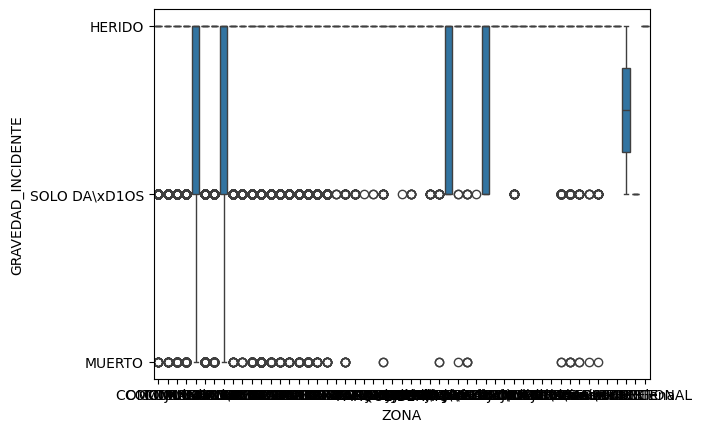

In [8]:
# Boxplot
# box plot Diagrama de caja y bigotes por continente
sns.boxplot(x = 'ZONA', y = 'GRAVEDAD_INCIDENTE', data = datos)

# **3. Prueba de normalidad**

**Planteamos las hipótesis**

 $$ H_{0}:\text{Transport proviene de una distribución Normal}$$
 $$ H_{1}:\text{Transport NO proviene de una distribución Normal}$$

 Si el valor p es menor a 0.05 se debe rechazar H0

In [ ]:
media_Transport =datos['Transport'].mean()
varianza_Transport =datos['Transport'].var()
desvest_Transport =np.sqrt(varianza_Transport)

# Test de Kolmogorov-Smirnov contra una N(mu, sigma)
ks_statistic, p_value = stats.kstest(datos['Transport'], 'norm', args=(media_Transport, desvest_Transport))

print(f"KS statistic: {ks_statistic:.4f}, p-value: {p_value:.4f}")


KS statistic: 0.3764, p-value: 0.0000


Como 0.0000 < 0.05 se debe rechazar H0, entonces Transport NO proviene de una distribución Normal

En este caso debemos buscar una transformación de potencia que normalice la variable que no es normal. Primero ensayamos con logaritmo natural (Ln).

In [ ]:
#Obtenemos el logaritmo natural
L_Transport = np.log(datos['Transport'])

#Realizamos de nuevo el test de normalidad
media_Transport =L_Transport.mean()
varianza_Transport =L_Transport.var()
desvest_Transport =np.sqrt(varianza_Transport)

# Test de Kolmogorov-Smirnov contra una N(mu, sigma)
ks_statistic, p_value = stats.kstest(L_Transport, 'norm', args=(media_Transport, desvest_Transport))

print(f"KS statistic: {ks_statistic:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print(f"Como {p_value:.4f} < 0.05, se debe rechazar H0, lo que indica que NO existe NORMALIDAD en la variable")
else:
    print(f"Como {p_value:.4f} >= 0.05, no se rechaza H0, existe NORMALIDAD en la variable")


KS statistic: 0.1256, p-value: 0.5135
Como 0.5135 >= 0.05, no se rechaza H0, existe NORMALIDAD en la variable


In [ ]:
#Se adiciona la nueva columa al dataframe "datos"
datos['L_Transport'] = L_Transport

# **4. ANOVA**

**Planteamos las hipótesis**

 $$ H_{0}:\mu_{AMERICA}=\mu_{EUROPA}=\mu_{ASIA}=\mu_{OCEANÍA}$$
 $$ H_{1}: \text{al menos un par }\mu_{i}\neq\mu_{j}$$

 Si el valor p es menor a 0.05 se debe rechazar H0

In [ ]:
# ANOVA
print("\nANOVA:")
model = ols('L_Transport ~ C(Continent)', data=datos).fit()
anova_results = anova_lm(model)
print(anova_results)

print("\nInterpretation:")
p_anova = anova_results['PR(>F)'][0]
if p_anova < 0.05:
    print(f"Como {p_anova:.4f} < 0.05, se debe rechazar H0, lo que indica que El L_Transport promedio NO es igual en todos los continentes")
else:
    print(f"Como {p_anova:.4f} >= 0.05, no se rechaza H0, El L_Transport promedio es igual en todos los continentes")




ANOVA:
                df      sum_sq    mean_sq         F    PR(>F)
C(Continent)   3.0   35.650391  11.883464  3.497151  0.025203
Residual      36.0  122.329475   3.398041       NaN       NaN

Interpretation:
Como 0.0252 < 0.05, se debe rechazar H0, lo que indica que El L_Transport promedio NO es igual en todos los continentes


/tmp/ipykernel_846/1169880948.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_anova = anova_results['PR(>F)'][0]


"NOTA: Si NO se cumple la normalidad de la Y se debe realizar la prueba no paramétrica KRUSKAL-WALLIS en lugar de la prueba ANOVA y validar solo los supuestos de no autocorrelación y homoscedasticidad"

In [ ]:
#import scipy.stats as stats

## Assuming L_Transport is a list or array of values and Continent is a list or array of group labels
## Example:
## L_Transport = [...]
## Continent = [...]

## Perform Kruskal-Wallis H-test
# groups = {}
# for value, group in zip(L_Transport, datos['Continent']):
#     groups.setdefault(group, []).append(value)

# stat, p = stats.kruskal(*groups.values())

# print(f"Kruskal-Wallis statistic: {stat:.4f}, p-value: {p:.4f}")

# **5. Prueba de diferencia de medias**

Como el ANOVA resultó en que El L_Transport promedio NO es igual en todos los continentes, se debe determinar cuáles promedios son iguales o diferentes usando la prueba Tukey HSD:

**Para cada par de medias planteamos las hipótesis**

 $$ H_{0}:\mu_{i}=\mu_{j}$$
 $$ H_{1}:\mu_{i}\neq\mu_{j}$$
 Si el valor p es menor a 0.05 se debe rechazar H0

In [ ]:
# Post-hoc Tukey HSD test
print("\nPrueba de diferencia de medias (Tukey HSD):")
tukey = pairwise_tukeyhsd(endog=datos['L_Transport'], groups=datos['Continent'], alpha=0.05)
print(tukey.summary())


Prueba de diferencia de medias (Tukey HSD):
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
America    Asia  -0.8739   0.98 -6.9543  5.2065  False
America  Europa  -3.8152 0.0349 -7.4246 -0.2057   True
America Oceania  -2.8764 0.4134 -7.8411  2.0882  False
   Asia  Europa  -2.9413 0.4062 -7.9764  2.0938  False
   Asia Oceania  -2.0026 0.8116  -8.083  4.0779  False
 Europa Oceania   0.9387 0.8962 -2.6707  4.5482  False
------------------------------------------------------


# **6. Validación de supuestos**

**6.1 No Autocorrelación = Residuos aleatorios=Residuos independientes**

**Planteamos las hipótesis**

 $$ H_{0}:\text{No autocorrelación}$$
 $$ H_{1}:\text{Autocorrelación}$$

 Si el valor p es menor a 0.05 se debe rechazar H0

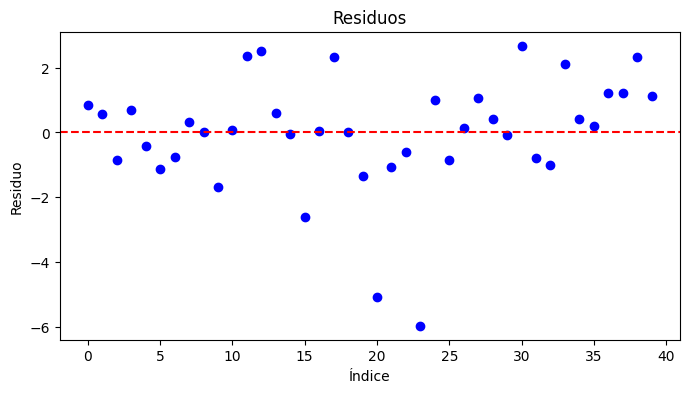

In [ ]:
#El gráfico de residuos
residuos = model.resid

plt.figure(figsize=(8, 4))
plt.scatter(range(len(residuos)), residuos, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos")
plt.xlabel("Índice")
plt.ylabel("Residuo")
plt.show()

In [ ]:
# Prueba de rachas (runs test)
z_stat, p_value = runstest_1samp(residuos)

print(f"La prueba de rachas es:\nZ = {z_stat}, p-valor = {p_value}")

if p_value < 0.05:
    print(f"Como {p_value:.4f} < 0.05, se debe rechazar H0, lo que indica que existe AUTOCORRELACIÓN")
else:
    print(f"Como {p_value:.4f} >= 0.05, no se rechaza H0, NO existe AUTOCORRELACIÓN")

La prueba de rachas es:
Z = -0.9020066914544321, p-valor = 0.36705331316215284
Como 0.3671 >= 0.05, no se rechaza H0, NO existe AUTOCORRELACIÓN


**6.2 Homoscedasticidad de los residuales**

**Planteamos las hipótesis**

 $$ H_{0}:\text{Homoscedasticidad en los residuales}$$
 $$ H_{1}:\text{Heteroscedasticidad en los residuales}$$

 Si el valor p es menor a 0.05 se debe rechazar H0

In [ ]:
# Homoscedasticity: Levene test
levene_stat, levene_p = levene(*[datos.loc[datos['Continent'] == c, 'L_Transport'] for c in datos['Continent'].unique()])
print(f"Levene test statistic: {levene_stat}, p-value: {levene_p}")

if levene_p < 0.05:
    print(f"Como {levene_p:.4f} < 0.05, se debe rechazar H0, lo que indica que existe HETEROSCEDASTICIDAD en los residuos")
else:
    print(f"Como {levene_p:.4f} >= 0.05, no se rechaza H0, existe HOMOSCEDASTICIDAD en los residuos")

Levene test statistic: 0.34442953027912127, p-value: 0.7933422206895688
Como 0.7933 >= 0.05, no se rechaza H0, existe HOMOSCEDASTICIDAD en los residuos


**6.3 Normalidad de los residuales**

**Planteamos las hipótesis**

 $$ H_{0}:\text{Los residuos provienen de una distribución Normal}$$
 $$ H_{1}:\text{Los residuos NO provienen de una distribución Normal}$$

 Si el valor p es menor a 0.05 se debe rechazar H0

In [ ]:
# 3. Normality of residuals: KS test
# Calculate residuals

ks_resid_stat, ks_resid_p = kstest(residuos, 'norm', args=(residuos.mean(), residuos.std()))
print(f"KS test on residuals statistic: {ks_resid_stat}, p-value: {ks_resid_p}")

if ks_resid_p < 0.05:
    print(f"Como {ks_resid_p:.4f} < 0.05, se debe rechazar H0, lo que indica que NO existe NORMALIDAD en los residuos")
else:
    print(f"Como {ks_resid_p:.4f} >= 0.05, no se rechaza H0, existe NORMALIDAD en los residuos")

KS test on residuals statistic: 0.13537332750761522, p-value: 0.41891704557232745
Como 0.4189 >= 0.05, no se rechaza H0, existe NORMALIDAD en los residuos
